<a href="https://colab.research.google.com/github/JonaJJSJ-crypto/Timedilation-with-CMS-open-Data/blob/main/Gu%C3%ADa_dilataci%C3%B3n_temporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install uproot fsspec-xrootd awkward vector numpy torch scikit-learn matplotlib seaborn pandas awkward-pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.8/405.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.7/698.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.4/187.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 45.8 MB/s eta 0:00:00


#**Un experiment para demostrar la dilatación temporal con el Mesón B con datos abiertos de CMS**

# **Objetivo:** Demostrar la dilatación temporal utilizando la distancia de vuelo media.
<b>Teoría</b>

Cada tipo de partícula tiene diferentes caracteristicas. Cada una tiene diferentes masas, tiempo de vida, decaimientos y muchas otras propiedades.

Para encontrar la distancia que viaja una partícula en su tiempo de vida, es necesario conocer la el tiempo exacto que vive la partícula y su velocidad. Clasicamente, la a formula para encontrar la distancia recorruda  en un vida de  $ d= vt. $ Donde $v$ es su velocidad y $t$ es el tiempo que vive al partícula antes de decaer.

Sin embargo, en muchos experimentos de física de partículas, las párticulas se mueven a velocidades cercanas a (pero simpre menor a!) la velocidad de la luz y esto significa que experimentan [dilatación temporal](https://en.wikipedia.org/wiki/Time_dilation), lo que significa que el reloj interno de las patículas se mueve mas lento.

Supongamos que una partícula vive una cantidad de tiempo igual a su [vida media](http://hyperphysics.phy-astr.gsu.edu/hbase/nuclear/meanlif.html) $ \tau $. Esta cantidad se define en el marco de referencia de reposo de la partícula, lo que significa que el tiempo que medimos en el laboratorio (en nuestro experimento) es generalmente mayor. Un cantidad muy útil que necesitamos es la distancia de vuelo: la distancia que recorre una particual entre su creación y su decaimiento. La distancia medida en el laboratorio es el [camino libre medio](http://geant4.web.cern.ch/geant4/G4UsersDocuments/UsersGuides/PhysicsReferenceManual/html/node13.html) y esta dado por:

$$L = \gamma \beta c \tau$$

donde $\beta = v/c$ y $\gamma = \frac{1}{\sqrt{1-\beta^2}}$.

*Credits to: Matthew Bellis*

# Selección del Mesón B
Entre otras partículas, las distancias de vuelo promedio del mesón B se pueden medir fácilmente utilizando datos abiertos del LHC. En un detector como el CMS, la evidencia de la existencia de un mesón B se obtiene indirectamente a través de la reconstrucción de sus productos de desintegración, ya que los mesones B son partículas altamente inestables con una vida útil muy corta que viajan solo una fracción de milímetro antes de desintegrarse. A continuación, se presentan las características principales para que sea nuestro candidato:

*   **Vértice de desintegración desplazado:** Debido a su corta vida útil pero a una velocidad cercana a la de la luz, los mesones B viajan una distancia medible (micrómetros a milímetros) desde el punto donde fueron producidos (vértice primario) antes de desintegrarse. Sus productos de desintegración (por ejemplo, piones, kaones, muones) se originan en un punto diferente al del vértice primario, conocido como vértice secundario. Los sistemas de tracking del detector CMS pueden reconstruir las trayectorias de estas partículas cargadas con alta precisión y determinar que no se originan en el vértice de interacción principal.

*   **Reconstrucción de la masa invariante:** Una vez que se identifica un conjunto de partículas que podrían ser productos de desintegración de un mesón B (por ejemplo, un $J/\psi$ y un kaón), se reconstruye su masa invariante. Si estas partículas realmente se originan de un mesón B, la masa invariante de su combinación debería formar un pico que coincida con la masa conocida del mesón B (por ejemplo, alrededor de $5.279 \text{ GeV}/c^2$ para $B^0$ y $B^\pm$).

*   **Canales de desintegración característicos:** Los mesones B tienen modos de desintegración bien estudiados. Por ejemplo:
    *   **Desintegraciones a $J/\psi + K$:** Un canal muy limpio es $B \to J/\psi + K$. La partícula $J/\psi$ se desintegra rápidamente en un par de muones ($J/\psi \to \mu^+\mu^-$), que son fáciles de identificar en los detectores de muones del CMS y producen trazas limpias. La reconstrucción de la masa invariante de los dos muones identifica el $J/\psi$, y su combinación con la masa de un kaón identificado permite la reconstrucción del mesón B. **Este es el canal seleccionado para este análisis.**
    *   **Desintegraciones semileptónicas:** Un mesón B puede desintegrarse en un leptón cargado (electrón o muón) más un neutrino y otras partículas (por ejemplo, $B \to D + l + \nu$). La presencia de un leptón de alta energía junto con energía transversal faltante (debido al neutrino no detectado) es una firma clave.

*   **Identificación de partículas:** El CMS utiliza sus subsistemas (seguimiento, calorímetros, cámaras de muones) para identificar partículas individuales (muones, electrones, piones, kaones) y sus cargas, lo cual es esencial para reconstruir correctamente las desintegraciones.

En resumen, el mesón B es un candidato ideal. Su detección en el CMS se puede lograr mediante un proceso de detección de vértice secundario, reconstrucción de la masa invariante de los productos de desintegración e identificación precisa de partículas.

**Criterios de Selección Experimental basados en (Metodología ATLAS 2012):**
  *   **Calidad del ajuste del vértice:** Los candidatos a $B$ deben satisfacer $p_T^B > 8.0\text{ GeV}$ y $|\eta_B| < 2.5$. Para rechazar combinaciones de trazas falsas, el ajuste del vértice $\chi^2/\text{ndf}$ debe ser $< 2.0$ para $B_s^0 \to \mu^+\mu^-$ (85% de eficiencia) y $< 6.0$ para los otros canales (99.5% de eficiencia).
  *   **Ventanas de masa de señal y banda lateral:**
    *   $B_s^0 \to \mu^+\mu^-$: Región de señal $[5066, 5666]\text{ MeV}$; Bandas laterales $[4766, 5066]\text{ MeV}$ y $[5666, 5966]\text{ MeV}$.
    *   $B^\pm \to J/\psi K^\pm$: Región de señal $[5180, 5380]\text{ MeV}$; Bandas laterales $[4930, 5130]\text{ MeV}$ y $[5430, 5630]\text{ MeV}$.

Colaboración ATLAS • Georges Aad (Freiburg U.) et al.

e-Print: 1204.0735 [hep-ex]

DOI: 10.1016/j.physletb.2012.06.013

Publicado en: Phys.Lett.B 713 (2012), 387-407



*   https://arxiv.org/pdf/2407.13441
*   https://www.sciencedirect.com/science/article/abs/pii/S0370269300010935
*   https://lss.fnal.gov/archive/thesis/2000/fermilab-thesis-2005-27.pdf


#Paso 1: Selección de base de datos

## Seleccione un set de Datos experimentales desde el poratl de datos abiertos del CERN. Recuerde que es importante que el set de Datos analizado tenga presencia del Mesón B.

El analisis empieza por seleccionar un set de datos experimentales encontrados en el [portal de datos abierto del CERN](https://opendata.cern.ch/). Se puede encontrar un [guía detallada](https://cms-opendata-workshop.github.io/workshop2026-lesson-nanoaod/) en el material del curso [CMS Open Data Workshop](https://indico.cern.ch/event/1672496/).

En nuestro caso seleccionamos el set de datos [charmonium](http://doi.org/10.7483/OPENDATA.CMS.JIO5.7GB6), ya que se conoce tiene presencia de mesones B.

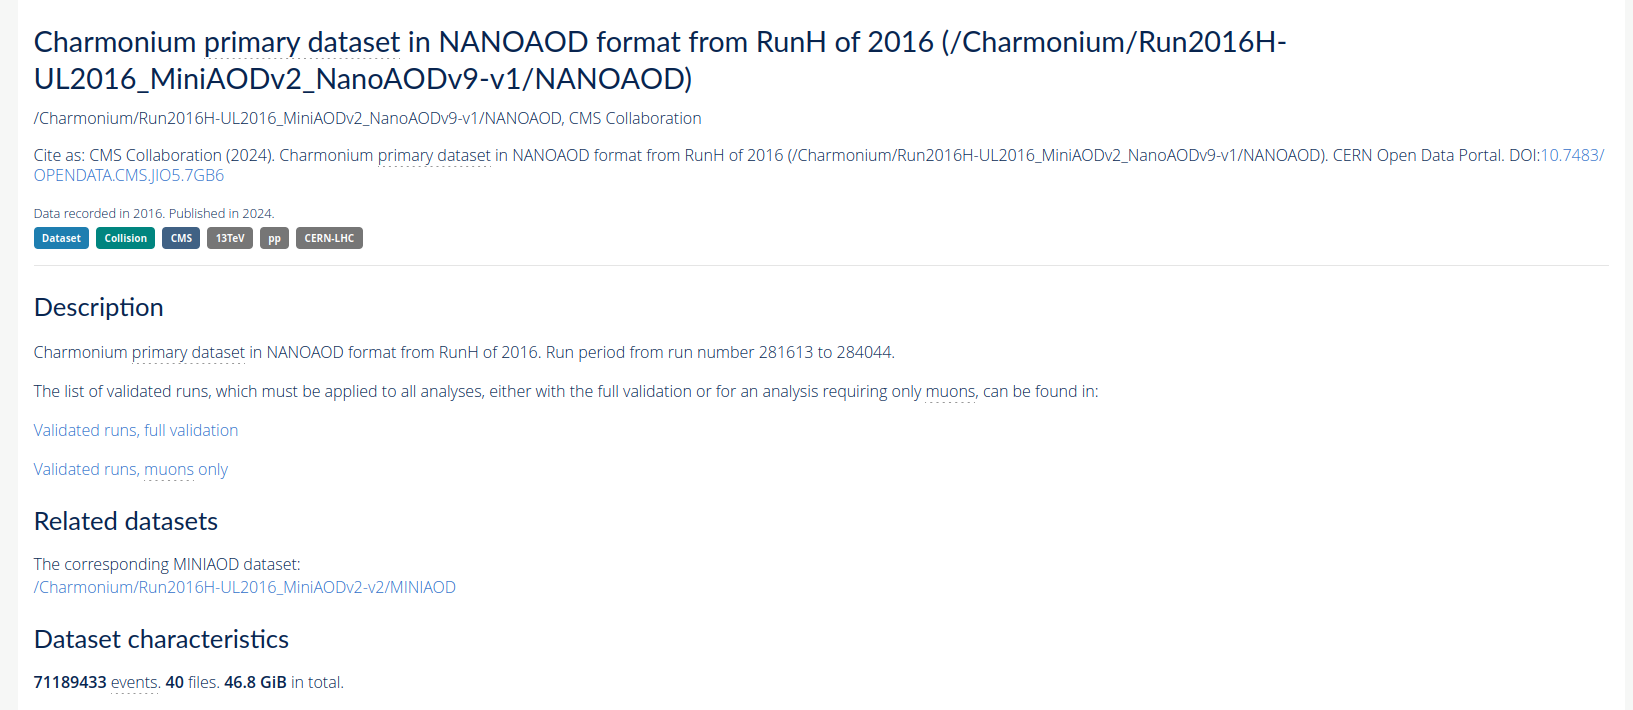





Observamos que este set de datos tiene informacion 71189433 colisiones, pesa 46.8 GiB y tiene 40 archivos que lo componen.

En general todos los archivos deben tener un contenido muy similar entre ellos pero con eventos de colisión distintos. Un análisis riguroso debería usar la totalidad del set de datos, pero esto se limita mucho por los recursos computacionales que tenemos disponibles. Un archivo muy grande puede tomar mucho tiempo en analizar o incluso saturar la memoria RAM del computador.

En nuestro caso utilizamos el archivo con código 00FA3E09-0BB7-FA4B-9F0B-B2D1EDAB9A76.root. Los códigos de los archivos se los puede encontrar al final de la pagina del dataset en la sección **Files and Indexes**
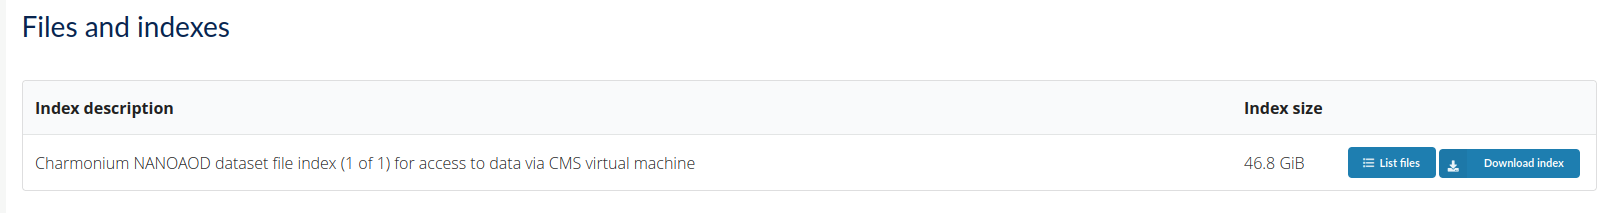





#Paso 2: Adquisición de base de datos

## Analice el contenido del set de datos seleccionados y cargue un archivo al entorno de Jupyter.

Los datos de las colisiones observadas en el LHC se almacenan en formato root. El formato root se caracteriza por ser un archivo binario que reduce mucho el espacio en memoria pero requiere de rutinas especializadas para su acceso y edición.

Los archivos del portal de datos abiertos del CERN se pueden adquirir por medio del protocolo xrootd. En nuestro entorno de Jupyter podemos ademas cargar y editar estos archivos utilizando la librería uproot.



In [ ]:
#Se importa la libreria Uproot al entorno
import uproot

#Se ingresa el enlace con protocolo xrootd
charmonium_0 = "root://eospublic.cern.ch//eos/opendata/cms/Run2016G/Charmonium/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/270000/00FA3E09-0BB7-FA4B-9F0B-B2D1EDAB9A76.root"

#Se almacenan los datos de los eventos del archivo root
events = uproot.open(charmonium_0)["Events"]

###*Nota:*
*Es importante destacar que los datos adquiridos para este ejercicio tiene un formato NanoAOD. Este tipo de formato tiene mucho preprocesamiento de reconstrucción de cantidades físicas. Esto significa que en este tipo específico de Formato se encuentra ya la reconstrucción de vértices secundarios, su cálculo de masa invariante, su distancia de vuelo, entre muchas otras.*

*Sin embargo, en el mismo portal de datos abiertos podemos encontrar datos en otro nivel de preprocesamiento denominados MiniAOD o AOD. La información de muchas cantidades físicas en estos datos no estan disponibles. Esto permite al investigador crear sus propias rutinas, por ejemplo, para reconstrucción de vértices desplazados. Pero a cambio de esta libertad se deberá realizar análisis más exhaustivosy manejar una mayor cantidad de datos.*


#Paso 3: Explorando el archivo root

## Identifique las variables de interes y cargelos al entorno de Jupyter. Recuerde que en nuestro caso analizaremos vértices secundarios.

Para conocer mejor el contenido de los archivos root puede revisar la [guía detallada](https://cms-opendata-workshop.github.io/workshop2026-lesson-particle-physics-primer/instructor/index.html).

En nuestro ejercicio nos enfocaremos en encontrar los datos de los vertices secundarios. La nomenclatura exacta dentro de nuestro datos se pueden encontrar en la sección **Dataset semantics** en la página de charmonium.
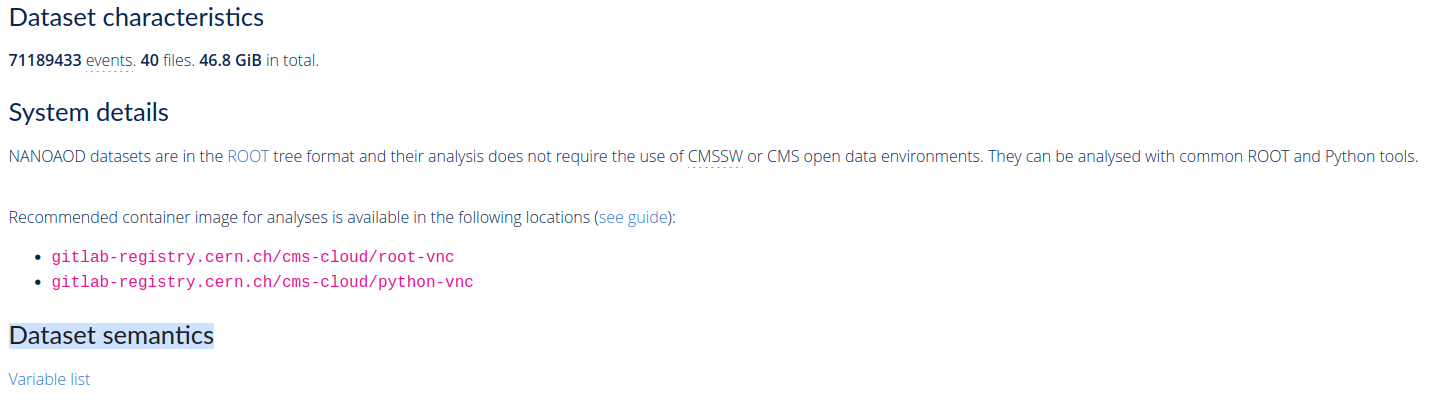

En nuestro set de datos la información de vertices secundarios tiene el prefijo "sv". En el bloque de código se debe declarar las variables a las que queremos acceder. Y con eso se extrae directamente del contenedor de evento que creamos en el paso anterior.
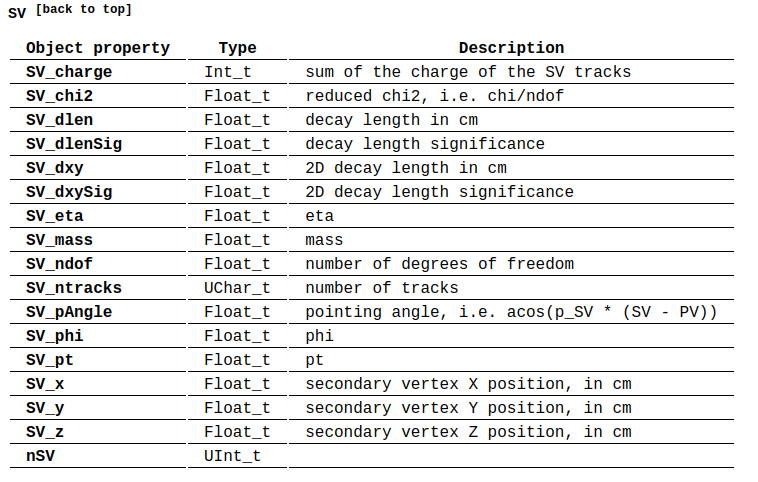

Es importante considerar que en el archivo root la información se agrupa por eventos. Es ocasiona que vamos a tener entradas de datos en las que existan vertices desplazados con nuestro Mesón B y otros en que no. Por ello decidimos colapsar la lista y en almacenar el número de envento como una variable con ayuda de la libreria **Awkwardarray**. Esto también nos ayuda a organizar los datos en una estructura bidimensional tipo DataFrame con ayuda de la libreria **Pandas**.

In [ ]:
#Se invocan la librerias Awkward array y pandas
import awkward as ak
import pandas as pd

#Se almacena el nombre de las variables ecnotrada en el Data Schematics
sv_variables = [
    'SV_charge',
    'SV_chi2',
    'SV_dlen',
    'SV_dlenSig',
    'SV_dxy',
    'SV_dxySig',
    'SV_eta',
    'SV_mass',
    'SV_ndof',
    'SV_ntracks',
    'SV_pAngle',
    'SV_phi',
    'SV_pt',
    'SV_x',
    'SV_y',
    'SV_z'
]

#Se extrae y se colapsa cada variable de sv del contenedor de eventos
sv_data = {}
for var in sv_variables:
    sv_data[var] = ak.flatten(events[var].array())

#Se extrae el número de evento para cada vértice secundario y se almacena como una variable
sv_event_number_lists = []
e_sv = 0
for sv_per_event in events['SV_charge'].array(): # Use any SV array to get event structure
  e_sv += 1
  sv_event_number_lists.append(len(sv_per_event)*[e_sv])
flat_event_n_sv = ak.flatten(sv_event_number_lists)
sv_data['event_n_sv'] = flat_event_n_sv

#Se convierte los datos a formato DataFrame
df_sv = pd.DataFrame(sv_data)

#Se imprime el set de datos acondicionado para quality check
print(df_sv.head(10))
print(f"DataFrame for Secondary Vertices created with {len(df_sv)} entries.")

   SV_charge   SV_chi2   SV_dlen  SV_dlenSig    SV_dxy   SV_dxySig    SV_eta  \
0         -2  1.199219  2.199219    3.457031  0.489502    3.500000  2.200195   
1          1  1.070312  0.636719   31.578125  0.335693   30.906250  1.265137   
2          0  1.250000  0.124512    4.613281  0.054993    4.031250 -1.348389   
3          0  1.085938  0.293213   11.585938  0.123413   11.109375 -1.536133   
4          0  0.493164  0.371582   30.500000  0.270752   27.171875  0.772217   
5          2  0.105957  0.642578   18.171875  0.573242   18.531250 -0.531860   
6          0  0.223633  7.675781  322.500000  6.687500  321.750000 -0.536865   
7          0  0.390625  0.323242   15.484375  0.196899   15.578125  1.107910   
8          0  0.589844  0.203491    8.390625  0.094971    8.773438 -1.485107   
9         -1  0.143555  0.510254   52.968750  0.508301   53.093750 -0.091812   

    SV_mass   SV_ndof  SV_ntracks  SV_pAngle    SV_phi      SV_pt      SV_x  \
0  0.341309  0.906250           2   3.11

#Paso 4: Análisis de Masas Invariantes y seleeción del Mesón B
## Grafique un histograma de la distribución de masas invariantes para todos los vértices secundarios. Identifique el pico caracteristico que señala la presencia del Mesón B. Seleccione los datos destinados al análisis.
Vamos a analizar la la distribución estadística de masas invariantes. de los vértices secundarios

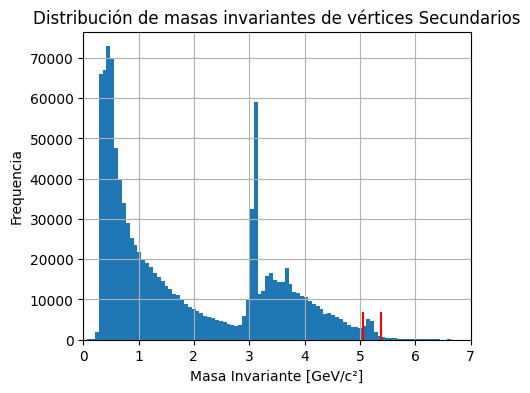

In [ ]:
# Se importa la libreria para Gráficos
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4)) # Se define las dimensiones del gráfico
plt.hist(df_sv['SV_mass'], bins=100, range=(0, 7)) # Se grafica un histograma de masas invariantes de los vértices desplazados
plt.vlines([5.06,5.38], ymin=0,ymax=7000, color="r") # Se grafican lineas verticales rojas en los limites definidos en la literatura

# Etiquetas y formato del gráfico
plt.xlabel('Masa Invariante [GeV/c²]')
plt.ylabel('Frequencia')
plt.title('Distribución de masas invariantes de vértices Secundarios')
plt.grid(True)
#plt.yscale('log')
plt.xlim(0,7)
plt.show()

Realizamos un zoom para poder apreciar mejor la resonancia del mesón B.

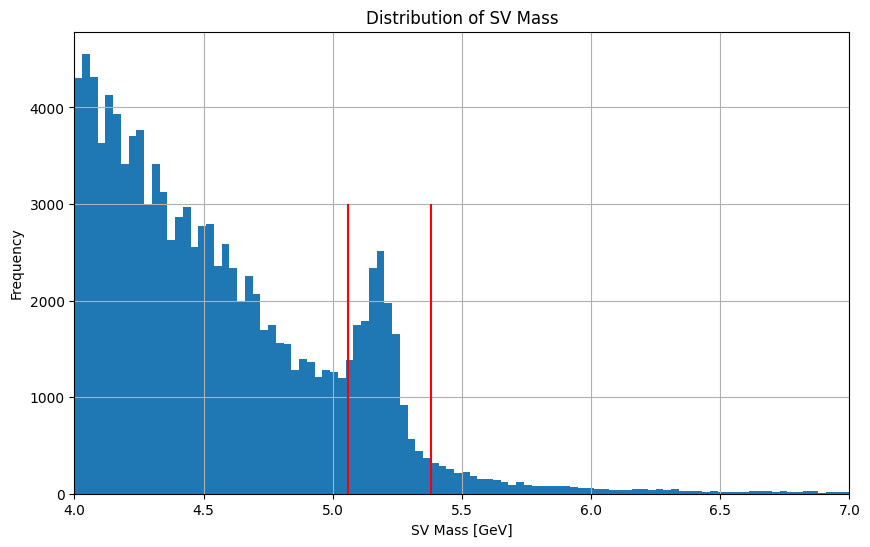

In [ ]:
# Se importa la libreria para Gráficos
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Se define las dimensiones del gráfico. En este casó se define un gráfico mas grande
plt.hist(df_sv['SV_mass'], bins=100, range=(4,7)) # Se modifica el limite del histograma al rango (4,7)GeV
plt.vlines([5.06,5.38], ymin=0,ymax=3000, color="r") # Se corrigió el orden de los argumentos

# Etiquetas y formato del gráfico
plt.xlabel('SV Mass [GeV]')
plt.ylabel('Frequency')
plt.title('Distribution of SV Mass')
plt.grid(True)
#plt.yscale('log')
plt.xlim(4,7)
plt.show()

Seleccionamos los vertices secundarios de acuerdo a:

1.   Corte en Masa invariante en el rango [5.06,5.38] GeV/c².
2.   Significancia de la distancia de vuelo mayor ao igual a 2.
3.   Y ajuste del vértice $\chi^2/\text{ndf}$ debe ser $< 2.0$ (85% de eficiencia)



In [ ]:
# Se seleccionan datos con formato condicional de DataFrame
df_sv_Bcut = df_sv[(df_sv['SV_mass'] >= 5.06) &
                              (df_sv['SV_mass'] <= 5.380) &
                              (df_sv['SV_dlenSig'] >= 2.0)&
                              (df_sv['SV_chi2']/df_sv['SV_ndof'] <= 2)]
df_sv_Bcut

,SV_charge,SV_chi2,SV_dlen,SV_dlenSig,SV_dxy,SV_dxySig,SV_eta,SV_mass,SV_ndof,SV_ntracks,SV_pAngle,SV_phi,SV_pt,SV_x,SV_y,SV_z,event_n_sv
67,-1,0.884766,0.294922,30.859375,0.287109,30.734375,0.225006,5.140625,6.703125,5,3.119141,-2.984375,33.625000,-0.227417,0.062866,-0.462234,91
159,-1,1.109375,0.168213,15.921875,0.105896,14.375000,1.008301,5.203125,2.781250,3,3.095703,-0.334290,19.515625,0.162720,0.064148,-1.043091,224
189,-1,0.853516,0.191772,4.937500,0.070984,4.929688,1.660645,5.234375,6.625000,5,3.134766,2.255371,55.218750,0.011604,0.157959,2.827637,259
279,-1,0.728516,0.221313,17.843750,0.144775,17.609375,-1.009033,5.140625,6.703125,5,3.111328,2.809570,18.921875,-0.078979,0.144287,-0.257385,367
310,-1,0.308594,0.292480,33.187500,0.246460,32.718750,-0.594482,5.132812,2.890625,3,3.134766,2.530273,27.546875,-0.143311,0.243164,5.166748,411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130394,0,1.238281,0.632324,35.781250,0.515137,35.656250,0.665283,5.109375,4.578125,4,3.134766,-3.026855,54.406250,-0.454834,0.047913,2.426025,1607363
1130493,1,1.441406,0.435059,21.734375,0.425781,21.750000,-0.218414,5.062500,2.664062,3,3.130859,-2.659668,91.625000,-0.321777,-0.092407,-1.782715,1607517
1130559,1,1.628906,0.143799,7.355469,0.084229,7.042969,1.124268,5.296875,2.554688,3,3.126953,-1.475342,41.375000,0.065735,0.024841,1.132019,1607612
1130734,-1,0.081543,0.199463,18.890625,0.174194,19.265625,-0.581055,5.167969,2.906250,3,3.099609,-1.257324,32.093750,0.108704,-0.057739,1.516602,1607834


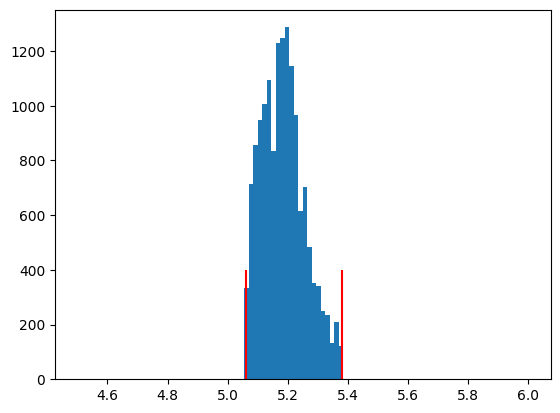

In [ ]:
#Gráfico de datos recortados
plt.hist(df_sv_Bcut['SV_mass'], bins=100, range=(4.5,6))
plt.vlines([5.06,5.38], ymin=0,ymax=400, color="r")

#Paso 5: Análisis de vértices secundarios


##Analice el modelo teórico y obtenga la relación entre la distancia de vuelo media $L$ y el momentum lineal $p$. Grafique la dispersión entre la distancia de vuelo transversal ```SV_dxy``` y el momentum transversal ```SV_pt``` y relacionelo con el modelo teórico

Si reemplazamos el momento lineal relativista $p = \gamma \beta c m$ de la partícula y lo introducimos dentro de la expersión de distancia de vuelo media $L$ obtenemos que:
$$L = \gamma \beta c \tau = \left(\frac{p}{m}\right) c \tau.$$

Notamos que debeía haber una relación lineal entre la distancia de vuelo media de una partícula y el momento lineal relativista. Si calculamos la pendiente de la relación para el mesón B tenemos que $\frac{c \tau}{m} = 9.311735\times 10^{-5} m/GeV$

Momento promedio de los datos pt: 31.758457
Pendiente esperada: 9.311735e-05
Pendiente calculada: 8.504954e-05


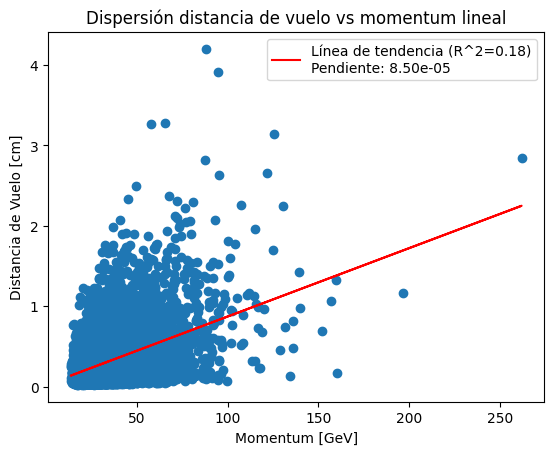

In [ ]:
# Libreria para gráficar y para analisis estadístico
import matplotlib.pyplot as plt
from scipy import stats

#Definición de varialbes para el ajuste lineal
x = df_sv_Bcut['SV_pt']
y = df_sv_Bcut['SV_dxy']

#Gráfico de dispersión para Momentum y distancia de vuelo
plt.scatter(x, y)
plt.xlabel('Momentum [GeV]')
plt.ylabel('Distancia de Vuelo [cm]')

# Cálculo de regresión lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Gráfico de la lniea de tendencia en color rojo
plt.plot(x, intercept + slope * x, color='red', label=f'Línea de tendencia (R^2={r_value**2:.2f})\nPendiente: {slope/100:.2e}')

#Calculo de variables
avrg_pt = df_sv_Bcut['SV_pt'].mean() #momento promedio
c = 299792458 # (m/s) velocidad e la luz
tau = 1.64e-12 # (s) tiempo de vída media del Mesón B
mass = 5.28 # (GeV) Masa del Mesón B

expected_slope = c * tau / mass # pendiente teórica de la relacion distnaica de vuelo - momentum lineal

#Se imprimen los cálculos
print(f"Momento promedio de los datos pt: {avrg_pt:3f}")
print(f"Pendiente esperada: {expected_slope:3e}")
print(f"Pendiente calculada: {slope/100:3e}")

#Etiquetas del gráfico
plt.title('Dispersión distancia de vuelo vs momentum lineal')
plt.legend()
plt.show()


Al graficar la dispersión con los vértices seleccionados calculamos tambien una linea de tendencia. Observamos que la linea de tendencia refleja la naturaleza probabilista del tiempo de vida media de una partícula. Es decir que dos partículas con un identicas en masa velocidad y todas sus características pueden viviar mas o menos tiempo. y por tanto desplzarse mas o menos. Eso se nota al dispersión de datos aparentemente caótica. Dado que esta distribución en promedio debe ajustar al modelo teoríco observamos que la pendiente $ 8.504954\times 10^{-5} m/GeV$ de la linea de tendencía se aproxima al modelo teórico.

# Paso 6: Linealización de los datos
## Para linealizar los datos separe los datos en ```Q``` cuantiles. Para cada cuantil obtenga la distancia de vuelo promedio y el momentum promedio. Obtenga la relación lineal entre Distancia de vuelo promedio y momentum promedio, relacionelo con el modelo teórico.

Finalmente se ordenan los vertices secundarios de menor a mayor momentum lineal, y se separa en ```Q=10``` cuantiles. El residuo de la disión se descarta en la cola mas energética por ser la menos representativa en los datos. Para cada cuantil se obtienen el promedio de distanica de vuelo y momentum lineal transversal. y con estos valores se obtiene un regrresión lineal con su pendiente y r-cuadrado.


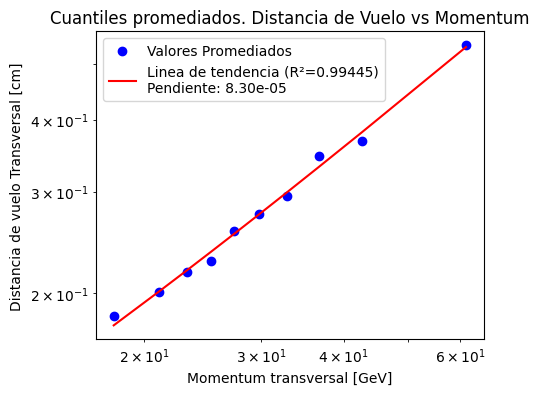

Promedio de cuantiles : 8.2987e-05
R-cuadrado para promedio de cuantiles: 0.9944
Intercepto: 0.0266
Error porcentual de la pendiente: 10.88%


In [ ]:
#Librerias de Gŕaficos, analisis estadístico y analisis numérico
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

Q = 10 #Numero de cuantiles
pt_means = [] #vector para momentos promedios
dxy_means = [] #vector para distancias promedios
df_ordered = df_sv_Bcut[['SV_pt','SV_dxy']].sort_values(by='SV_pt') #Datos ordenados por momentum lineal

n = int(np.round(len(df_ordered)/Q)) # numero de vertices secundarios por cuantil

#Calculo de momento y distnacia promedio para cada cuantil
for i in range(0, len(df_ordered), n):
    df_ncut = df_ordered.iloc[i:i+n]

    if len(df_ncut) > 30:
        pt_means.append(df_ncut['SV_pt'].mean())
        dxy_means.append(df_ncut['SV_dxy'].mean())

# Regresión lineal on los promedios por cuantil
slope, intercept, r_value, p_value, std_err = stats.linregress(pt_means, dxy_means)

# Grafico de promedios por cuantil
plt.figure(figsize=(5,4))
plt.scatter(pt_means, dxy_means, color='blue', marker='o', label='Valores Promediados')

#Linea de tendencia de la regresión lineal
plt.plot(pt_means, intercept + slope * np.array(pt_means), color='red', label=f'Linea de tendencia (R²={r_value**2:.5f})\nPendiente: {slope/100:.2e}')

#Etiquetas del gráfico
plt.xlabel('Momentum transversal [GeV]')
plt.ylabel('Distancia de vuelo Transversal [cm]')
plt.title('Cuantiles promediados. Distancia de Vuelo vs Momentum')
plt.grid(True)
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.show()

print(f"Promedio de cuantiles : {slope/100:.4e}")
print(f"R-cuadrado para promedio de cuantiles: {r_value**2:.4f}")
print(f"Intercepto: {intercept:.4f}")
print(f"Error porcentual de la pendiente: {np.abs(slope/100 - expected_slope)/expected_slope*100:.2f}%")

Se puede observar que el las distancia de vuelo y el momento lineal promediado pro cuantiles ajusta mejro el modelo teórico. Se nota que existe una alta dispersión ($R^2 = 0.9944$) que denota que estamos realizando una sobresimplificación del análisis. Así mismo, el análisis de pendientes denota la relación entre nuestros datos y el modelo teórico ($E_\% = 10.88$ %). Estos resultados se pueden mejorar realizando un ajuste de factores de la distribucion exponencial de la vida media de las partículas, pero esto mismo limitaría la accesibilidad a estudiantes universitarios.

Nótese que los valores obtenidos en este análisis son estimadores de $L$ y $p$.

#Paso 7: Compare sus resultados con el modelo teórico y deduzca la dialtación temporal

Como paso final se analizan las distancias de vuelo en función del porcentaje de la velocidad de la Luz. Se grafican la distancia de vuelo media predicha por la teoría clásica, que se observa es muhco menor a la observada en los datos. Así mismo se grafica la distancia de vuelo si nuestra partícula pudiese viajar a la velocidad de la luz. Y finalmente se grafíca la distnacia de vuelo media con la dilatación temporal de la vida media. Se grafican también las distnacias promediadas de los cuantiles en función de la velocidad. Se puede apreciar como los datos experiemtnales ajustan adecuadamente al modelo teórico predicho por la relatividad especial.

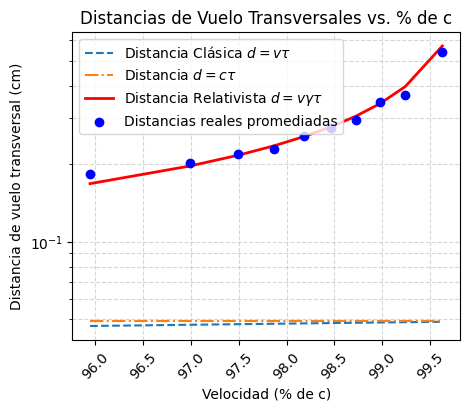

In [ ]:
# Calcula el factor relativista beta (v/c) a partir del momentum transversal (pt_means) y la masa (mass).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

beta_val = np.array(pt_means) / np.sqrt(np.array(pt_means)**2 + mass**2)

# Convierte beta a la velocidad física en m/s
velocity_ms = beta_val * c
ct = np.full_like(beta_val, c*tau)

# Grafica las distintas distancias de vuelo vs porcentaje de la velocidad de la luz
plt.figure(figsize=(5,4))

# Eje X: beta_val * 100 (Porcentaje de c)
# Eje Y: Distancias en cm
# Se usa r'...' para evitar advertencias de secuencias de escape inválidas con LaTeX
plt.plot(beta_val * 100, velocity_ms*tau*100, label=r'Distancia Clásica $d=v \tau$', linestyle='--')
plt.plot(beta_val * 100, ct*100, label=r'Distancia $d=c \tau$', linestyle='-.')
plt.plot(beta_val * 100, velocity_ms*tau/np.sqrt(1-(beta_val)**2)*100,color="red", label=r'Distancia Relativista $d=v \gamma \tau$', linewidth=2)
plt.scatter(beta_val * 100, np.array(dxy_means), color='blue', zorder=5, label='Distancias reales promediadas')

# Formato de los ejes
plt.xlabel('Velocidad (% de c)')
plt.ylabel('Distancia de vuelo transversal (cm)')
#plt.xscale('log')
plt.yscale('log')

# Configuración para evitar notación científica en las etiquetas del eje x
ax = plt.gca()
formatter = ScalarFormatter(useOffset=False, useMathText=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.title('Distancias de Vuelo Transversales vs. % de c')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tick_params(axis='x', rotation=45)
plt.show()

#Conclusión

En este análisis se analiza la dilatación temporal utilizando la vida media de observaciones de Mesones B en los datos abiertos del LHC en partícular de la colaboración CMS. Se utilizó el set de Datos Charmonium, donde se identificó la presencia del Mesón B utilizando la resonancia en la distribución de masas invariantes para vértices secundarios. Se segmentaron los datos considerando la masa invariante y la cálidad de la reconstrucción de los vértices secundarios. Se ajustaron los datos al modelo de distancia de vuelo media con dilatación temporal $L = \gamma \beta c \tau$ y momentum lineal relativista $p = \gamma \beta c m $. Se estimaron $L$ y $p$ segmentando los datos en cuantiles ordenados por momentum lineal, y se obtuvo una regresión lineal de los datos promediados.

Finalmente se obtuvo un factore de correlación ($R^2 = 0.9944$) y un error porcentual ($E_\% = 10.88$ %) entre la pendiente teórica ($\frac{c \tau}{m} = 9.3117\times 10^{-5} m/GeV$) y la pendiente experimental $8.2987\times 10^{-5} m/GeV$. Con estos resultados podemos confirmar que los mesones B observados en los datos abiertos de CMS tienden a vivir por más tiempo cuando mayor es su energía. Este fenómeno denominado dilatación temporal establece que el reloj interno de una partícula se realentiza cuando viaja a velocidades cercanas a las de la luz. Además, los resultados obtenidos en esta práctica sugieren que los datos ajustan con el modelo matemático predicho por Albert Einstein.

$$
t = \frac{\tau}{ \sqrt{1-\frac{v^2}{c^2}}}
$$